In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Importing data

# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

data_path = '/content/drive/MyDrive/olist/'

files = {
    'orders': 'olist_orders_dataset.csv',
    'customers': 'olist_customers_dataset.csv',
    'order_items': 'olist_order_items_dataset.csv',
    'order_payments': 'olist_order_payments_dataset.csv',
    'order_reviews': 'olist_order_reviews_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'sellers': 'olist_sellers_dataset.csv',
    'geolocation': 'olist_geolocation_dataset.csv',
    'category_translation': 'product_category_name_translation.csv',
}

data = {name: pd.read_csv(data_path + f) for name, f in files.items()}

# Convert date columns to datetime objects for the 'orders' dataframe
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    data['orders'][col] = pd.to_datetime(data['orders'][col])

Mounted at /content/drive


##**1. Parse Dates**

In [ ]:
# Datetime Conversion

date_cols = {
    'orders': ['order_purchase_timestamp', 'order_approved_at',
               'order_delivered_carrier_date', 'order_delivered_customer_date',
               'order_estimated_delivery_date'],
    'order_reviews': ['review_creation_date', 'review_answer_timestamp'],
    'order_items': ['shipping_limit_date'],
}

for name, cols in date_cols.items():
    for col in cols:
        data[name][col] = pd.to_datetime(data[name][col], errors='coerce')

print("✅ Dates parsed")
print("orders.dtypes:")
print(data['orders'].dtypes)

✅ Dates parsed
orders.dtypes:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


##**2. Deduplication Geolocation**

In [ ]:
# 26% exact duplicates - same zip/ity with repeated coordinates.

In [ ]:
# Geolocation dedup

before = len(data['geolocation'])
data['geolocation'].drop_duplicates(inplace=True)
print(f"geolocation: {before:,} → {len(data['geolocation']):,} rows (removed {before - len(data['geolocation']):,} dupes)")

geolocation: 1,000,163 → 738,332 rows (removed 261,831 dupes)


##**3. Products: Handling Missing Values**

In [ ]:
df_products = data['products']

# Filling missing category with 'unknown' (keeping the rows)
df_products['product_category_name'] = df_products['product_category_name'].fillna('unknown')

# Filling name/description/photos with 0 (they are counts/lengths)
for col in ['product_name_lenght', 'product_description_lenght', 'product_photos_qty']:
    df_products[col] = df_products[col].fillna(0)

# Drop the 2 rows missing physical attributes (trivial)
before = len(df_products)
df_products.dropna(subset=['product_weight_g'], inplace=True)
print(f"products: dropped {before - len(df_products)} rows with missing weight/dimensions")
print("Remaining missing:", df_products.isnull().sum().sum(), "✅")

products: dropped 2 rows with missing weight/dimensions
Remaining missing: 0 ✅


##**4. Translate Product Categories BR to GB**

In [ ]:
# Merge Translation

df_products = df_products.merge(
    data['category_translation'], on='product_category_name', how='left'
)
# Fallback for categories missing from translation table
df_products['product_category_name_english'] = df_products['product_category_name_english'].fillna('unknown')

print("Unique categories (EN):", df_products['product_category_name_english'].nunique())
df_products[['product_category_name', 'product_category_name_english']].drop_duplicates().head(10)

Unique categories (EN): 72


,product_category_name,product_category_name_english
0,perfumaria,perfumery
1,artes,art
2,esporte_lazer,sports_leisure
3,bebes,baby
4,utilidades_domesticas,housewares
5,instrumentos_musicais,musical_instruments
6,cool_stuff,cool_stuff
7,moveis_decoracao,furniture_decor
8,eletrodomesticos,home_appliances
9,brinquedos,toys


##**5. Building the MASTER Dataframe**

In [ ]:
# Join order on:
#      - customers (who bought)
#      - order_items → products, sellers (what & from whom)
#      - payments (how they paid)
#      - reviews (what they said)

#      ⚠️ `order_items`, `payments`, `reviews` can have multiple rows per order → use aggregation to avoid row explosion.

In [ ]:
# Aggregate Child Tables

# Payments: one row per order (sum amounts, count methods, take main type)
pay_agg = data['order_payments'].groupby('order_id').agg(
    payment_total=('payment_value', 'sum'),
    payment_installments=('payment_installments', 'max'),
    payment_types=('payment_type', lambda x: ', '.join(sorted(set(x))))
).reset_index()

# Reviews: one row per order (latest review)
rev_agg = (data['order_reviews'].sort_values('review_answer_timestamp')
           .groupby('order_id')
           .agg(review_score=('review_score', 'last'),
                review_comment=('review_comment_message', 'last'))
           .reset_index())

# Order items: one row per order (total items, total price+freight)
items_agg = data['order_items'].groupby('order_id').agg(
    total_items=('order_item_id', 'count'),
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum')
).reset_index()

In [ ]:
# Merging

master = (data['orders']
    .merge(data['customers'], on='customer_id', how='left')
    .merge(items_agg, on='order_id', how='left')
    .merge(pay_agg, on='order_id', how='left')
    .merge(rev_agg, on='order_id', how='left')
    # item-level detail: take first item's product/seller per order
    .merge(data['order_items'][['order_id', 'product_id', 'seller_id']]
           .drop_duplicates('order_id'), on='order_id', how='left')
    .merge(df_products[['product_id', 'product_category_name_english',
                        'product_weight_g', 'product_photos_qty']], on='product_id', how='left')
    .merge(data['sellers'][['seller_id', 'seller_state']], on='seller_id', how='left')
)

print(f"Master shape: {master.shape}")
master.head(3)

Master shape: (99441, 26)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_installments,payment_types,review_score,review_comment,product_id,seller_id,product_category_name_english,product_weight_g,product_photos_qty,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,"credit_card, voucher",4.0,"Não testei o produto ainda, mas ele veio corre...",87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,housewares,500.0,4.0,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,1.0,boleto,4.0,Muito bom o produto.,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,perfumery,400.0,1.0,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,3.0,credit_card,5.0,None,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,auto,420.0,1.0,SP


##**6. Delivery Features**

In [ ]:
# Actual delivery time (days)
master['delivery_days'] = (master['order_delivered_customer_date'] - master['order_purchase_timestamp']).dt.days
# Estimated vs actual
master['delivery_delay_days'] = (master['order_delivered_customer_date'] - master['order_estimated_delivery_date']).dt.days
# Was it late?
master['was_late'] = master['delivery_delay_days'] > 0
# Purchase month for time trends
master['purchase_month'] = master['order_purchase_timestamp'].dt.to_period('M')

print("Late deliveries:", f"{master['was_late'].mean()*100:.1f}%")
master[['delivery_days', 'delivery_delay_days', 'was_late']].describe()

Late deliveries: 6.6%


,delivery_days,delivery_delay_days
count,96476.000000,96476.000000
mean,12.094086,-11.876881
std,9.551746,10.183854
min,0.000000,-147.000000
25%,6.000000,-17.000000
50%,10.000000,-12.000000
75%,15.000000,-7.000000
max,209.000000,188.000000


##**7. Outlier Check**

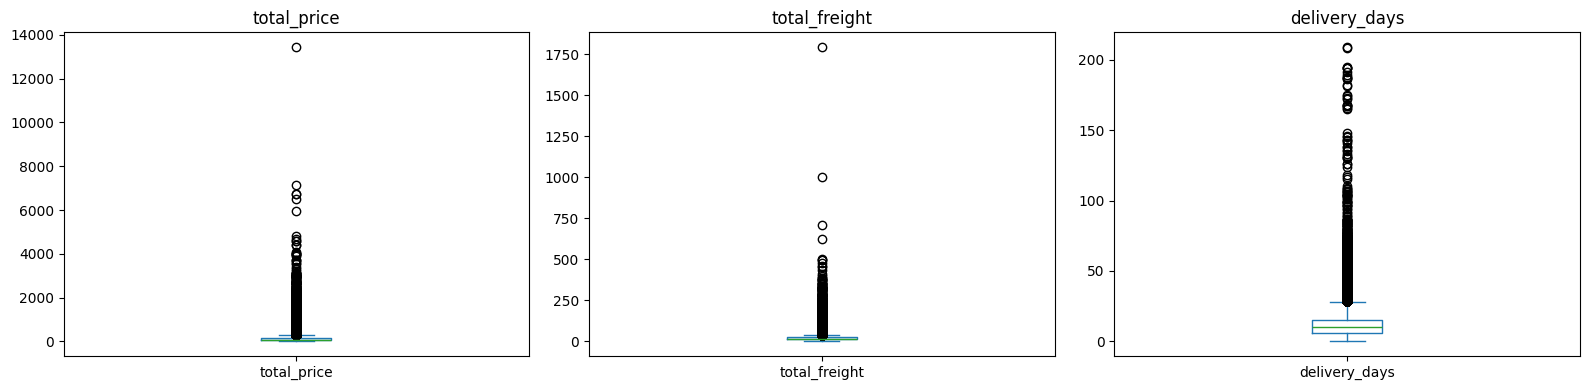

Price > 10k: 1 rows — likely B2B bulk orders, keep but note


In [ ]:
fig, axes = plt.subplots(1,3, figsize=(16, 4))
for ax, col in zip(axes, ['total_price', 'total_freight', 'delivery_days']):
    master[col].dropna().plot.box(ax=ax)
    ax.set_title(col)
plt.tight_layout(); plt.show()

print("Price > 10k:", (master['total_price'] > 10000).sum(), "rows — likely B2B bulk orders, keep but note")

In [ ]:
# Saving Master Dataset

# Local (session-only)
# master.to_csv('/content/olist_master.csv', index=False)

# Recommended: Google Drive (persists across sessions)
from google.colab import drive
drive.mount('/content/drive')
master.to_csv('/content/drive/MyDrive/olist_master.csv', index=False)

print(f"✅ Saved! Shape: {master.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved! Shape: (99441, 30)
